# Exploratory Data Analysis (EDA)

## Objetivo

Analizar la calidad de los datos, comprender el comportamiento de usuarios y productos, identificar patrones de consumo y detectar posibles riesgos para el modelado del sistema de recomendación.

## Preguntas de negocio

- ¿Existen problemas de calidad de datos?
- ¿Cómo se distribuyen las compras de los usuarios?
- ¿Cómo se distribuyen las compras de los productos?
- ¿Existe comportamiento Long Tail?
- ¿Existe sparsity significativa en la matriz usuario-producto?
- ¿Cuáles son los productos más populares?
- ¿Cómo se comportan los usuarios a lo largo del tiempo?

In [1]:
# Importar librerías para análisis exploratorio

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
# Cargar datasets principales

aisles = pd.read_csv("../data/raw/instacart/aisles.csv")
departments = pd.read_csv("../data/raw/instacart/departments.csv")
orders = pd.read_csv("../data/raw/instacart/orders.csv")
products = pd.read_csv("../data/raw/instacart/products.csv")
prior = pd.read_csv("../data/raw/instacart/order_products__prior.csv")
train = pd.read_csv("../data/raw/instacart/order_products__train.csv")

In [3]:
# Agrupar datasets para análisis de calidad

datasets = {
    "aisles": aisles,
    "departments": departments,
    "orders": orders,
    "products": products,
    "prior": prior,
    "train": train
}

In [4]:
# Analizar valores faltantes por tabla

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.isnull().sum())


AISLES
aisle_id    0
aisle       0
dtype: int64

DEPARTMENTS
department_id    0
department       0
dtype: int64

ORDERS
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

PRODUCTS
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

PRIOR
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

TRAIN
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64


In [5]:
# Analizar registros duplicados

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(f"Duplicados: {df.duplicated().sum()}")


AISLES
Duplicados: 0

DEPARTMENTS
Duplicados: 0

ORDERS
Duplicados: 0

PRODUCTS
Duplicados: 0

PRIOR
Duplicados: 0

TRAIN
Duplicados: 0


# Calidad de datos

## Valores faltantes

Se identificaron valores nulos únicamente en la columna `days_since_prior_order` de la tabla `orders`.

Estos valores corresponden al primer pedido realizado por cada usuario, por lo que representan una ausencia lógica de información y no un problema de calidad de datos.

## Duplicados

No se identificaron registros duplicados en ninguna de las tablas analizadas.

Por lo tanto, no será necesario realizar procesos de eliminación de duplicados durante la etapa de preparación de datos.

In [6]:
# Cantidad de pedidos por usuario

orders_per_user = (
    orders.groupby("user_id")
    .size()
    .reset_index(name="order_count")
)

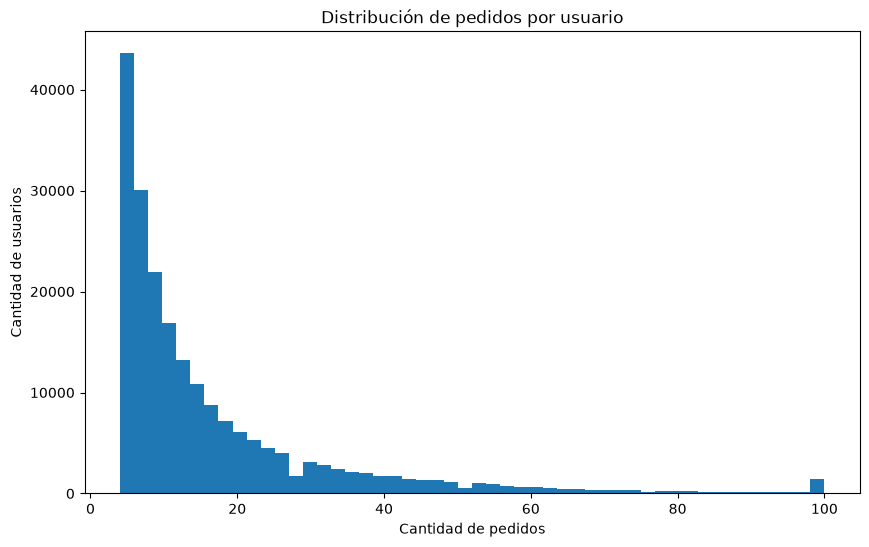

In [7]:
# Distribución de pedidos por usuario

plt.figure(figsize=(10,6))

plt.hist(
    orders_per_user["order_count"],
    bins=50
)

plt.title("Distribución de pedidos por usuario")
plt.xlabel("Cantidad de pedidos")
plt.ylabel("Cantidad de usuarios")

plt.show()

In [8]:
# Estadísticas descriptivas

orders_per_user["order_count"].describe()

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_count, dtype: float64

# Comportamiento de los usuarios

La distribución de pedidos por usuario presenta una fuerte asimetría positiva.

La mayoría de los usuarios registra una cantidad relativamente baja de pedidos, mientras que un grupo reducido concentra una gran actividad de compra.

## Hallazgos

- Promedio de pedidos por usuario: 16,59
- Mediana de pedidos por usuario: 10
- Máximo observado: 100 pedidos

Estos resultados indican que existe suficiente historial de interacción para construir perfiles de consumo personalizados.

Sin embargo, también se observa la presencia de usuarios con pocas compras, lo que introduce potenciales escenarios de Cold Start que deberán ser considerados durante el modelado.

In [9]:
# Cantidad de compras por producto

product_sales = (
    prior.groupby("product_id")
    .size()
    .reset_index(name="purchase_count")
)

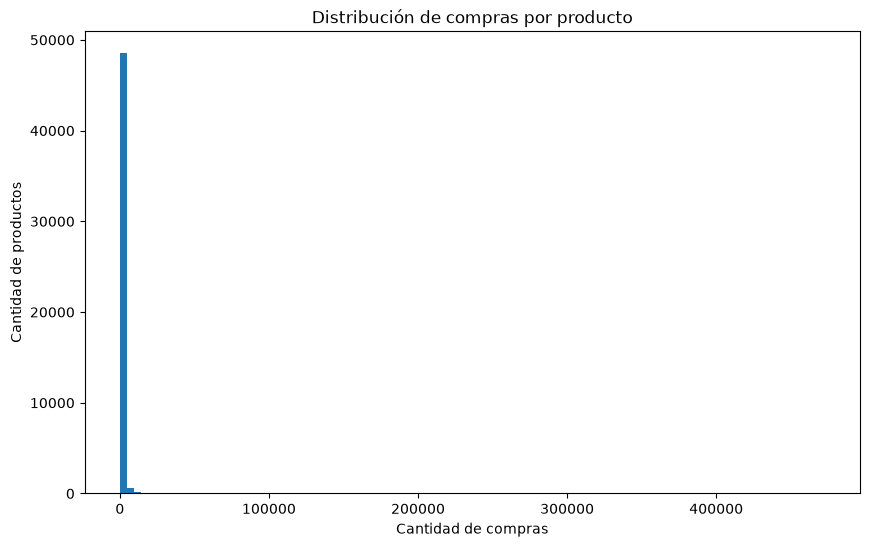

In [10]:
# Distribución de compras por producto

plt.figure(figsize=(10,6))

plt.hist(
    product_sales["purchase_count"],
    bins=100
)

plt.title("Distribución de compras por producto")
plt.xlabel("Cantidad de compras")
plt.ylabel("Cantidad de productos")

plt.show()

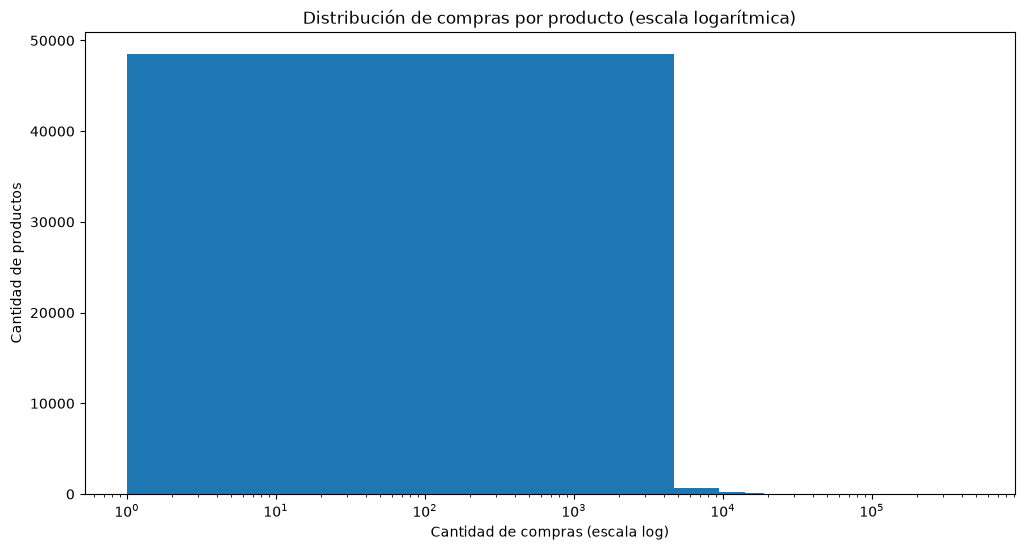

In [11]:
# Distribución de compras por producto (escala logarítmica)

plt.figure(figsize=(12,6))

plt.hist(
    product_sales["purchase_count"],
    bins=100
)

plt.xscale("log")

plt.title("Distribución de compras por producto (escala logarítmica)")
plt.xlabel("Cantidad de compras (escala log)")
plt.ylabel("Cantidad de productos")

plt.show()

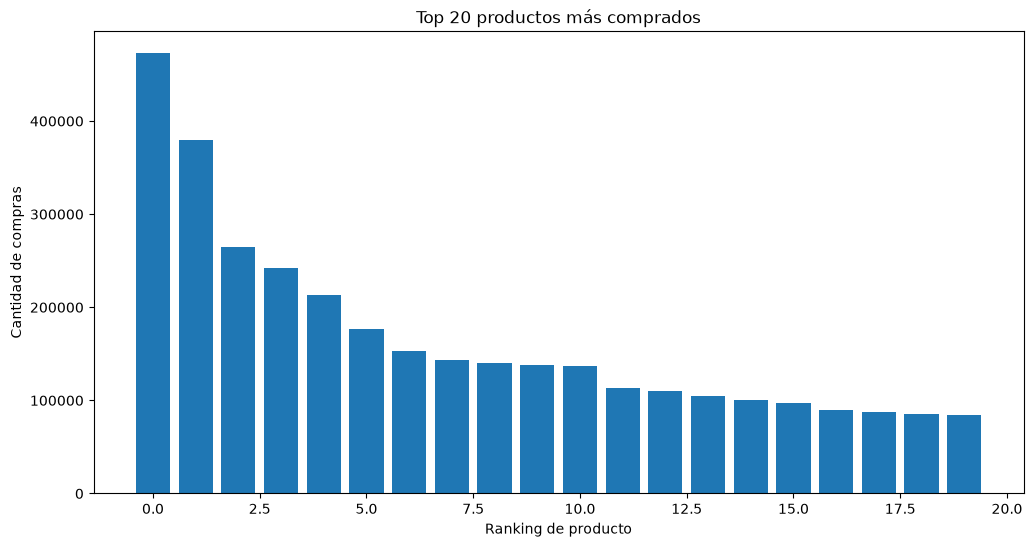

In [12]:
# Top 20 productos más comprados

top_products = (
    product_sales
    .sort_values("purchase_count", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top_products)),
    top_products["purchase_count"]
)

plt.title("Top 20 productos más comprados")
plt.xlabel("Ranking de producto")
plt.ylabel("Cantidad de compras")

plt.show()

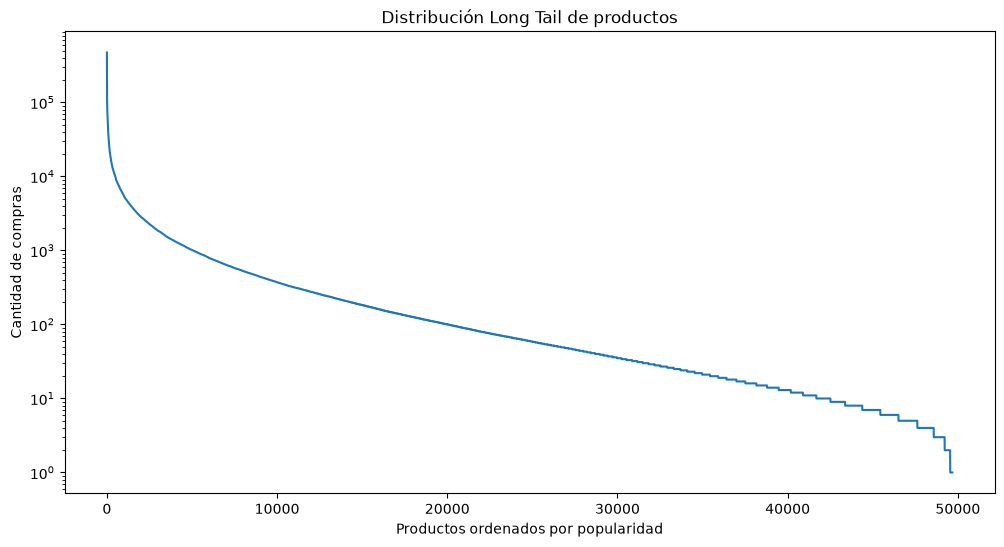

In [13]:
# Curva Long Tail

sales_sorted = (
    product_sales["purchase_count"]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(12,6))

plt.plot(sales_sorted)

plt.title("Distribución Long Tail de productos")
plt.xlabel("Productos ordenados por popularidad")
plt.ylabel("Cantidad de compras")

plt.yscale("log")

plt.show()

In [14]:
# Top 10 productos más comprados

product_sales.sort_values(
    by="purchase_count",
    ascending=False
).head(10)

,product_id,purchase_count
24848,24852,472565
13172,13176,379450
21133,21137,264683
21899,21903,241921
47198,47209,213584
47755,47766,176815
47615,47626,152657
16793,16797,142951
26204,26209,140627
27839,27845,137905


# Distribución de compras por producto

Se observa una distribución claramente asimétrica de las compras por producto.

Un grupo reducido de productos concentra una gran cantidad de compras, mientras que la mayoría del catálogo presenta una frecuencia de compra significativamente menor.

## Hallazgos

- El producto más comprado registra 472.565 compras.
- La mediana de compras por producto es de 60.
- El promedio de compras por producto es de 652.

La diferencia entre media y mediana evidencia una fuerte concentración de compras en pocos productos.

## Implicancias para el sistema de recomendación

Este comportamiento corresponde al fenómeno conocido como Long Tail, característico de plataformas de e-commerce.

Por este motivo, un sistema basado únicamente en popularidad tendería a recomendar siempre los mismos productos, limitando la personalización.

Se evaluarán modelos capaces de capturar preferencias individuales de los usuarios para recomendar productos menos populares pero potencialmente relevantes.

In [15]:
# Cantidad de pedidos por día de la semana

orders["order_dow"].value_counts().sort_index()

order_dow
0    600905
1    587478
2    467260
3    436972
4    426339
5    453368
6    448761
Name: count, dtype: int64

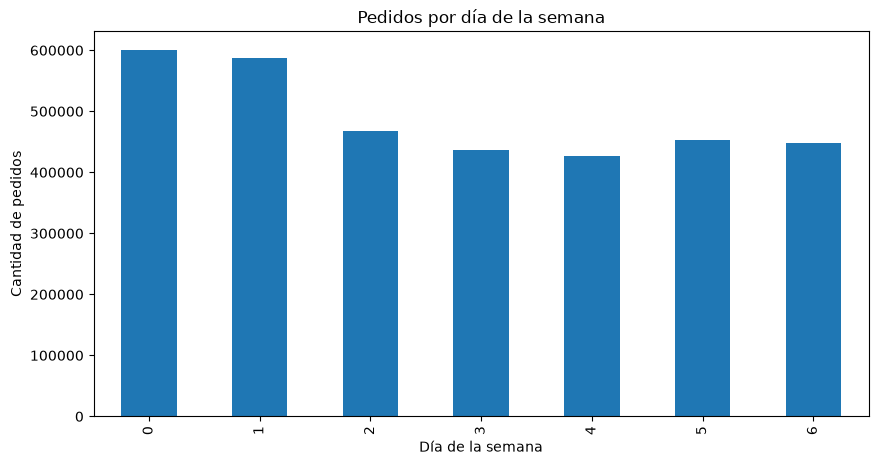

In [16]:
# Distribución de pedidos por día de la semana

orders["order_dow"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Pedidos por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de pedidos")

plt.show()

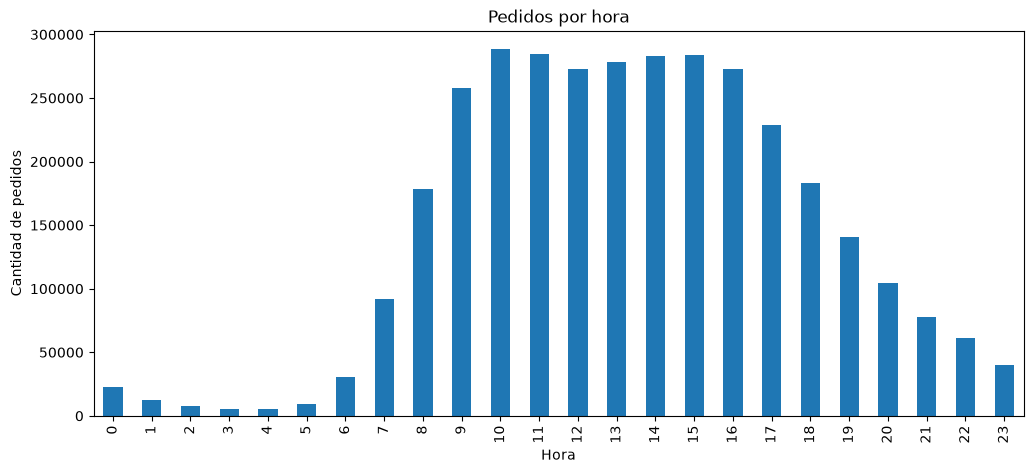

In [17]:
# Distribución de pedidos por hora del día

orders["order_hour_of_day"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Pedidos por hora")
plt.xlabel("Hora")
plt.ylabel("Cantidad de pedidos")

plt.show()

# Comportamiento temporal de compra

Se analizó la distribución de pedidos por día de la semana y por hora del día.

La variable `order_dow` representa el día de la semana en que se realizó el pedido. Sin embargo, antes de interpretar cada categoría será necesario confirmar la codificación utilizada por el dataset.

Por otro lado, la variable `order_hour_of_day` permite identificar patrones horarios de compra.

# Tamaño de las canastas de compra

Se analizó la cantidad de productos incluidos en cada pedido para comprender el comportamiento de compra de los usuarios y evaluar el potencial de técnicas de recomendación basadas en asociaciones entre productos.

In [18]:
basket_size = prior.groupby(
    "order_id"
).size()

basket_size.describe()

count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
dtype: float64

<Axes: >

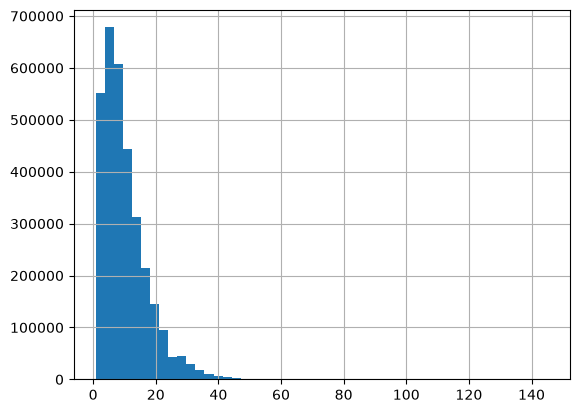

In [19]:
basket_size.hist(bins=50)

## Hallazgos

Se analizaron 3.214.874 pedidos históricos.

- El tamaño promedio de una canasta es de 10 productos.
- La mediana es de 8 productos por pedido.
- El 75% de los pedidos contiene hasta 14 productos.
- Existen pedidos con hasta 145 productos, aunque representan casos excepcionales.

La distribución presenta una asimetría positiva, con una gran concentración de pedidos pequeños y medianos, acompañada por una cola de pedidos de gran tamaño.

## Implicancias para el modelado

- Los pedidos contienen múltiples productos por transacción.
- Esto permite analizar relaciones entre productos comprados en conjunto.
- Existe potencial para aplicar técnicas de Market Basket Analysis y estrategias de Cross Selling.
- La presencia de múltiples productos por pedido permite construir recomendaciones complementarias además de recomendaciones personalizadas.

# Potencial para Market Basket Analysis

Dado que cada pedido contiene múltiples productos, resulta posible analizar asociaciones de compra entre artículos y generar recomendaciones complementarias.

In [20]:
# Analizar comportamiento de recompra

prior["reordered"].value_counts()

reordered
1    19126536
0    13307953
Name: count, dtype: int64

In [21]:
# Analizar porcentaje de recompra

prior["reordered"].value_counts(normalize=True) * 100

reordered
1    58.969747
0    41.030253
Name: proportion, dtype: float64

# Comportamiento de recompra

La variable `reordered` indica si un producto ya había sido comprado previamente por el usuario.

## Resultados

- 58,97% de las compras corresponden a productos previamente adquiridos.
- 41,03% corresponden a primeras compras.

## Hallazgo

Los usuarios presentan una fuerte tendencia a repetir compras de productos ya conocidos.

Este comportamiento resulta especialmente favorable para sistemas de recomendación basados en historial de consumo, ya que evidencia la existencia de patrones de preferencia estables a lo largo del tiempo.

## Implicancias para el modelado

La elevada tasa de recompra sugiere que técnicas de Collaborative Filtering y modelos basados en interacciones históricas podrían capturar adecuadamente las preferencias de los usuarios.

## Oportunidades de negocio

La alta tasa de recompra observada sugiere la existencia de hábitos de consumo recurrentes.

Esta característica no solo favorece la construcción de modelos de recomendación personalizados, sino que también podría utilizarse para identificar oportunidades de recompra automática, promociones dirigidas y estrategias de fidelización de clientes.

# Implicancias para el sistema de recomendación

A partir del análisis exploratorio realizado se identificaron características relevantes del dataset que impactarán directamente en las decisiones de modelado.

Las siguientes observaciones permiten justificar la elección de los algoritmos a evaluar y anticipar posibles limitaciones del sistema.

## Sparsity de la matriz usuario-producto

La matriz usuario-producto presenta una dispersión aproximada del 99,68%.

### Implicancias

- La mayoría de los usuarios interactúa únicamente con una pequeña porción del catálogo.
- Los enfoques basados únicamente en reglas simples o popularidad pueden resultar insuficientes.
- Será necesario evaluar modelos capaces de aprender patrones a partir de interacciones parciales entre usuarios y productos.

## Long Tail de productos

La distribución de compras presenta un comportamiento Long Tail.

Un grupo reducido de productos concentra gran parte de las compras, mientras que la mayoría del catálogo registra una baja frecuencia de consumo.

### Implicancias

- Un recomendador basado únicamente en popularidad tenderá a recomendar siempre los mismos productos.
- Resulta importante evaluar modelos que permitan descubrir productos relevantes más allá de los más vendidos.
- Se utilizará un modelo baseline basado en popularidad para comparar su desempeño contra modelos personalizados.

## Comportamiento de recompra

El 58,97% de las compras corresponde a productos adquiridos previamente por los usuarios.

### Implicancias

- Existen patrones de consumo estables.
- Los usuarios muestran preferencias recurrentes.
- Los modelos basados en historial de consumo tienen potencial para capturar dichas preferencias.

## Cold Start

Se observan usuarios con poca actividad dentro del sistema.

### Implicancias

- Algunos usuarios contarán con información limitada para generar recomendaciones personalizadas.
- Este escenario representa un desafío conocido como Cold Start.
- Los modelos deberán contemplar mecanismos alternativos para usuarios con escaso historial.

## Estrategia preliminar de modelado

A partir de los hallazgos obtenidos durante el EDA se decidió evaluar inicialmente dos enfoques:

1. Modelo Baseline basado en popularidad de productos.
2. Modelo de Collaborative Filtering basado en interacciones usuario-producto.

La comparación entre ambos permitirá determinar si la personalización aporta mejoras respecto de una estrategia simple basada en productos populares.

Adicionalmente, se explorará la posibilidad de incorporar técnicas de Market Basket Analysis para identificar productos frecuentemente comprados en conjunto y generar recomendaciones orientadas a Cross Selling.

Este enfoque permitiría complementar las recomendaciones personalizadas con sugerencias de productos asociados a patrones reales de compra.

# Conclusiones generales del EDA

El análisis exploratorio permitió comprender la estructura del dataset, validar la calidad de los datos e identificar patrones relevantes para el desarrollo del sistema de recomendación.

## Principales hallazgos

- Alta concentración de compras en un grupo reducido de productos.
- Presencia de comportamiento Long Tail en el catálogo.
- Elevada tasa de recompra de productos (58,97%).
- Alta sparsity en la matriz usuario-producto.
- Diferencias significativas en el nivel de actividad de los usuarios.
- Potencial para aplicar modelos basados en comportamiento histórico.
- Potencial para identificar asociaciones entre productos y generar estrategias de Cross Selling.

## Implicancias para el modelado

Los resultados obtenidos justifican la evaluación de distintos enfoques de recomendación:

- Modelo Baseline basado en popularidad.
- Collaborative Filtering basado en interacciones usuario-producto.
- Posibles técnicas de Market Basket Analysis para identificar productos frecuentemente comprados en conjunto.

La comparación entre estos enfoques permitirá determinar qué estrategia genera recomendaciones más relevantes para los usuarios.

## Próximos pasos

- Data Preprocessing.
- Feature Engineering.
- Construcción de modelos Baseline.
- Implementación de Collaborative Filtering.
- Exploración de Market Basket Analysis.
- Evaluación mediante métricas específicas de recomendación.
- Desarrollo de API y dashboard interactivo.